<a href="https://colab.research.google.com/github/Victor-HugoMvp/Rap1-apiComputacaoGrafica/blob/main/Rap1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcairo2-dev is already the newest version (1.16.0-5ubuntu2.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Início da Prática
Executando Passo 1: Criando imagem vetorial...


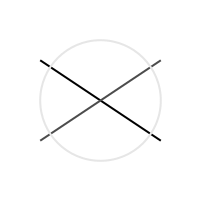

Executando Passo 2: Desenha círculo matricial...


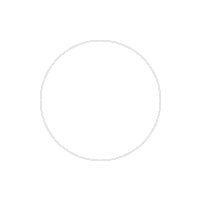

Executando Passo 3: Conversão Vetorial para Matricial...


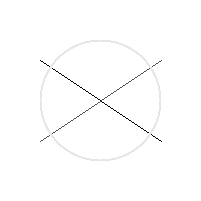

In [ ]:
# Instalação da biblioteca necessária para gráficos vetoriais
!apt-get install libcairo2-dev
!pip install pycairo

import cairo
import numpy as np
from PIL import Image
import math

# --- FUNÇÕES AUXILIARES E IMPLEMENTAÇÕES ---

def criaImagemVetorial():
    """
    Passo 1: Cria uma imagem vetorial SVG com retas e um círculo.
    """
    # Inicializa superfície SVG de 201x201 (tamanho para facilitar conversão posterior)
    surface = cairo.SVGSurface("cgpi1.svg", 201, 201)
    context = cairo.Context(surface)

    # Normaliza escala para 0.0 a 1.0 para seguir as coordenadas do roteiro
    context.scale(201, 201)

    # b. Segmento de reta preto (0.2, 0.3) até (0.8, 0.7)
    context.set_source_rgb(0, 0, 0) # Preto
    context.set_line_width(0.01)
    context.move_to(0.2, 0.3)
    context.line_to(0.8, 0.7)
    context.stroke()

    # c. Segmento de reta cinza escuro (0.8, 0.3) até (0.2, 0.7)
    context.set_source_rgb(0.3, 0.3, 0.3) # Cinza escuro
    context.move_to(0.8, 0.3)
    context.line_to(0.2, 0.7)
    context.stroke()

    # d. Círculo cinza claro, centro (0.5, 0.5), raio 0.3
    context.set_source_rgb(0.9, 0.9, 0.9) # Cinza claro (g=230 aprox)
    context.arc(0.5, 0.5, 0.3, 0, 2 * math.pi)
    context.stroke() # e. Salva chamando stroke

    return surface # f. Retorna v

def desenhaCirculo(f, c, r, g):
    """
    Passo 2: Desenha um círculo em uma matriz NumPy.
    Implementação básica baseada na equação do círculo.
    """
    xc, yc = c
    for y in range(f.shape[0]):
        for x in range(f.shape[1]):
            # Calcula distância do ponto ao centro
            dist = math.sqrt((x - xc)**2 + (y - yc)**2)
            if abs(dist - r) < 1.0: # Desenha a borda do círculo
                f[y, x] = g

def desenhaReta(f, p, q, g):
    """
    Passo 3: Desenha uma reta em uma matriz NumPy.
    Implementação usando algoritmo simples de amostragem.
    """
    x1, y1 = p
    x2, y2 = q
    dx = x2 - x1
    dy = y2 - y1
    steps = max(abs(dx), abs(dy))

    if steps == 0:
        f[y1, x1] = g
        return

    x_inc = dx / steps
    y_inc = dy / steps

    x, y = x1, y1
    for _ in range(int(steps) + 1):
        if 0 <= round(x) < f.shape[1] and 0 <= round(y) < f.shape[0]:
            f[round(y), round(x)] = g
        x += x_inc
        y += y_inc

# --- PROCEDIMENTOS DA ATIVIDADE ---

def passo1():
    print("Executando Passo 1: Criando imagem vetorial...")
    v = criaImagemVetorial() #
    # Para salvar como PNG no Colab a partir do Cairo:
    v.write_to_png("cgpi1.png") #
    display(Image.open("cgpi1.png"))

def passo2():
    print("Executando Passo 2: Desenha círculo matricial...")
    # 2. Cria matriz 201x201 branca (255)
    f = np.full((201, 201), 255, dtype=np.uint8)

    # 4. Desenha círculo cinza claro (g=230), centro (100,100), raio 60
    desenhaCirculo(f, (100, 100), 60, 230)

    # 5. Salva e exibe
    Image.fromarray(f).save("passo2.png")
    display(Image.open("passo2.png"))

def passo3():
    print("Executando Passo 3: Conversão Vetorial para Matricial...")
    # 2. Cria imagem matricial 201x201
    f = np.full((201, 201), 255, dtype=np.uint8)

    # 3. Desenha primeiro segmento (preto, g=0)
    # (0.2, 0.3) a (0.8, 0.7) -> round(coord * 201)
    p1 = (round(0.2*201), round(0.3*201))
    q1 = (round(0.8*201), round(0.7*201))
    desenhaReta(f, p1, q1, 0)

    # 4. Desenha segundo segmento (cinza escuro, g=80)
    p2 = (round(0.8*201), round(0.3*201))
    q2 = (round(0.2*201), round(0.7*201))
    desenhaReta(f, p2, q2, 80)

    # 5. Desenha círculo (cinza claro, g=230)
    centro = (round(0.5*201), round(0.5*201))
    raio = round(0.3*201)
    desenhaCirculo(f, centro, raio, 230)

    # Salva e exibe resultado final
    Image.fromarray(f).save("cgpi1_matricial.png")
    display(Image.open("cgpi1_matricial.png"))

# Execução do programa
print("Início da Prática")
passo1()
passo2()
passo3()